<a href="https://colab.research.google.com/github/Aderson79/dataset_colab/blob/main/INEP_REND_TECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projeto de Análise de Dados: Tecnologia e Rendimento Escolar no Piauí (2024)**
**Professor(a): Maria Hellem**

**Grupo: Aderson Mesquita e Erlandson Junior**

##**Objetivo do Projeto**
Este notebook tem como objetivo analisar o impacto da infraestrutura tecnológica no rendimento dos alunos do Ensino Médio da rede estadual do Piauí. Investigaremos se a disponibilidade de equipamentos digitais e acesso à rede influenciam diretamente nas taxas de aprovação e abandono escolar.

##**Roteiro de Execução (Pipeline de Dados)**
Para atender à Estrutura Mínima exigida, o projeto seguirá as seguintes etapas:


1.   **Ingestão de Dados**: Carregamento dos Microdados do Censo Escolar 2024 e das Planilhas de Rendimento do INEP.

2.   **Pré-processamento e Integração**: Limpeza de colunas, tratamento de valores nulos e realização do Join (cruzamento) entre as bases de infraestrutura e desempenho.

3.  **Engenharia de Indicadores**: Criação dos indicadores IID (Índice de Infraestrutura Digital) e DTA (Densidade Tecnológica por Aluno).

4.  **Análise Estatística Descritiva**: Cálculo de médias, medianas e desvios padrão para entender a dispersão dos dados na rede estadual.

5. **Visualização e Análise**: Geração de gráficos de dispersão com linhas de tendência para validar a correlação entre tecnologia e evasão.

6. **Conclusão e Tomada de Decisão**: Síntese dos achados e proposição de recomendações baseadas em evidências de dados.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path_microdados = '/content/microdados_ed_basica_2024.csv'
path_rendimento = '/content/tx_rend_escolas_2024.xlsx'

print("Carregando Microdados (CSV)...")
colunas_infra = [
    'CO_ENTIDADE', 'NO_MUNICIPIO', 'SG_UF', 'TP_DEPENDENCIA', 'IN_MED',
    'IN_LABORATORIO_INFORMATICA', 'QT_DESKTOP_ALUNO', 'QT_TABLET_ALUNO',
    'IN_INTERNET', 'IN_BANDA_LARGA', 'QT_MAT_MED'
]
df_micro = pd.read_csv(path_microdados, sep=';', encoding='latin1', usecols=colunas_infra, low_memory=False)

print("Carregando Rendimento (Excel)...")
df_rend = pd.read_excel(path_rendimento, header=7)

print("Dados carregados com sucesso!")

Carregando Microdados (CSV)...
Carregando Rendimento (Excel)...
Dados carregados com sucesso!


#**1. Problema do Grupo**
O objetivo deste projeto é investigar se a infraestrutura tecnológica das escolas estaduais do Piauí influencia o rendimento escolar dos alunos do Ensino Médio. **Buscamos responder**: A maior disponibilidade de equipamentos digitais está associada a menores taxas de abandono escolar?

#**2. Descrição do Dataset**
Utilizamos o cruzamento de duas fontes de dados oficiais do INEP (2024):

*   **Microdados do Censo Escolar**: Informações sobre infraestrutura (laboratórios, internet, banda larga) e matrículas.
*   **Indicadores de Rendimento**: Taxas de aprovação e abandono por unidade escolar.

In [24]:
# --- 1. FILTRAGEM INICIAL (Garantindo que trabalhamos apenas com o PI) ---
df_pi = df_micro[(df_micro['SG_UF'] == 'PI') &
                 (df_micro['TP_DEPENDENCIA'] == 2) &
                 (df_micro['IN_MED'] == 1)].copy()

# --- 2. LIMPEZA PRÉVIA DO RENDIMENTO ---
df_rend.columns = [str(c).strip() for c in df_rend.columns]

# Identificando as colunas (Ajustado para o padrão INEP Ensino Médio)
col_entidade_rend = df_rend.columns[5]
col_aprov_real = df_rend.columns[19]
col_aband_real = df_rend.columns[57]

# --- 3. PREPARAÇÃO PARA O JOIN ---
df_pi['CO_ENTIDADE'] = df_pi['CO_ENTIDADE'].astype(str).str.strip()
df_rend['CO_ENTIDADE_JOIN'] = df_rend[col_entidade_rend].astype(str).str.split('.').str[0].str.strip()

# --- 4. EXECUÇÃO DO MERGE ---
df_final = pd.merge(df_pi, df_rend, left_on='CO_ENTIDADE', right_on='CO_ENTIDADE_JOIN', how='inner')

# --- 5. TRATAMENTO DE DADOS E INDICADORES (Item 4 do PDF) ---
df_final['TAXA_APROVACAO'] = pd.to_numeric(df_final[col_aprov_real].astype(str).replace('--', np.nan), errors='coerce')
df_final['TAXA_ABANDONO'] = pd.to_numeric(df_final[col_aband_real].astype(str).replace('--', np.nan), errors='coerce')

# IID: Agora com 3 componentes (Lab + Internet + Banda Larga)
df_final['IID'] = (df_final['IN_LABORATORIO_INFORMATICA'].fillna(0) +
                   df_final['IN_INTERNET'].fillna(0) +
                   df_final['IN_BANDA_LARGA'].fillna(0))

# DTA: Densidade Tecnológica
df_final['TOTAL_COMP'] = df_final['QT_DESKTOP_ALUNO'].fillna(0) + df_final['QT_TABLET_ALUNO'].fillna(0)
df_final['DTA'] = df_final['TOTAL_COMP'] / df_final['QT_MAT_MED'].replace(0, 1)

# Filtro de qualidade: Mantendo apenas dados válidos
df_analise = df_final[df_final['TAXA_APROVACAO'] > 0].copy()

print(f"\nSucesso! {len(df_analise)} escolas processadas.")
display(df_analise[['NO_MUNICIPIO', 'TAXA_APROVACAO', 'TAXA_ABANDONO', 'IID', 'DTA']].head())


Sucesso! 114 escolas processadas.


,NO_MUNICIPIO,TAXA_APROVACAO,TAXA_ABANDONO,IID,DTA
4,Alagoinha do Piauí,100.0,3.9,2.0,0.216561
7,Alto Longá,100.0,3.4,1.0,0.010101
9,Altos,91.7,3.6,1.0,0.024793
10,Altos,88.5,0.0,1.0,0.278481
11,Altos,76.0,0.0,3.0,0.435897


#**3. Indicadores (com justificativa)**
Para quantificar o acesso digital, desenvolvemos dois indicadores sintéticos:


*   **IID (Índice de Infraestrutura Digital)**: Soma binária da presença de laboratório de informática, acesso à internet e banda larga. Justifica-se para medir o "piso tecnológico" da escola.
*   **DTA (Densidade Tecnológica por Aluno)**: Proporção de computadores (desktops e tablets) por aluno matriculado. Justifica-se para avaliar a disponibilidade real do recurso, eliminando distorções causadas pelo tamanho da escola.


In [25]:
# Gerando a estatística descritiva formatada
estatisticas = df_analise[['TAXA_APROVACAO', 'TAXA_ABANDONO', 'IID', 'DTA']].describe().T
estatisticas['median'] = df_analise[['TAXA_APROVACAO', 'TAXA_ABANDONO', 'IID', 'DTA']].median()

print("TABELA PARA O TRABALHO: ESTATÍSTICA DESCRITIVA (PI)")
display(estatisticas[['mean', 'std', 'median', 'min', 'max']].style.format("{:.2f}"))

TABELA PARA O TRABALHO: ESTATÍSTICA DESCRITIVA (PI)


,mean,std,median,min,max
TAXA_APROVACAO,97.42,5.36,100.00,69.20,100.00
TAXA_ABANDONO,2.81,5.22,0.90,0.00,36.40
IID,2.01,0.68,2.00,1.00,3.00
DTA,0.20,0.34,0.09,0.00,2.36


#**4. Estatística Descritiva (com interpretação)**
##**Interpretação dos Dados**:


*   **Rendimento**: A rede estadual apresenta uma média de aprovação altíssima (97.42%). Entretanto, o desvio padrão do abandono (5.22) indica uma rede heterogênea, onde casos isolados chegam a 36.40% de evasão.
*   **Acesso Digital**: O IID médio de 2.01 sugere que a maioria das escolas possui ao menos dois dos três itens básicos. Contudo, a mediana do DTA (0.09) revela que 50% das escolas possuem menos de 1 computador para cada 10 alunos, evidenciando um gargalo no acesso individual.






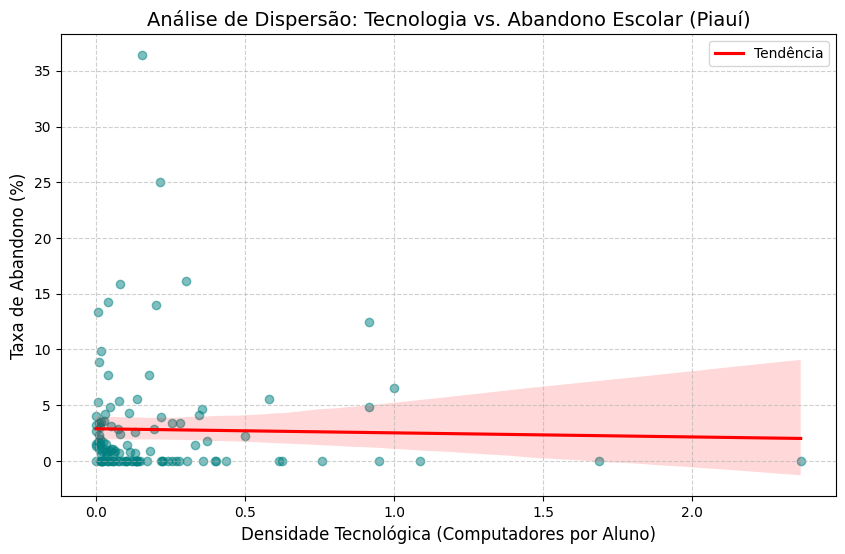

In [27]:
# --- CÉLULA DE VISUALIZAÇÃO: ANÁLISE DE IMPACTO ---

plt.figure(figsize=(10, 6))

# O regplot do Seaborn é ideal para Ciência de Dados pois faz duas coisas ao mesmo tempo:
# 1. Cria o gráfico de dispersão (os pontos representando cada escola)
# 2. Calcula e desenha a Linha de Regressão Linear (a linha vermelha de tendência)
sns.regplot(
    data=df_analise,
    x='DTA',            # Eixo X: Causa (Densidade Tecnológica)
    y='TAXA_ABANDONO',  # Eixo Y: Efeito (Taxa de Abandono)

    scatter_kws={'alpha':0.5, 'color':'teal'},
    line_kws={'color':'red', 'label':'Tendência'}
)

# Customização de títulos e legendas (Essencial para a 'Estrutura Mínima')
plt.title('Análise de Dispersão: Tecnologia vs. Abandono Escolar (Piauí)', fontsize=14)
plt.xlabel('Densidade Tecnológica (Computadores por Aluno)', fontsize=12)
plt.ylabel('Taxa de Abandono (%)', fontsize=12)

# Adicionamos a legenda e a grade para facilitar a leitura dos valores específicos
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

##**5. Visualizações (com análise)**
O gráfico de dispersão revela uma tendência de **correlação negativa** entre a **Densidade Tecnológica** e o **Abandono Escolar**. Observa-se que escolas com DTA próximo a zero apresentam maior volatilidade e picos de abandono escolar. À medida que o investimento em hardware aumenta (DTA > 0.5), a taxa de abandono tende a se estabilizar em patamares baixos, sugerindo que a tecnologia atua como um fator de engajamento e retenção.

#**6. Conclusão e Decisão**
##**Conclusão**:
Os dados corroboram a hipótese de que a precariedade tecnológica está associada a maiores riscos de evasão escolar no Piauí. O impacto da tecnologia não é apenas pedagógico, mas também social, auxiliando na permanência do aluno na escola.

##**Decisão Sugerida**:
Recomendamos que a Secretaria de Educação (SEDUC-PI) adote o DTA como critério de priorização para o Plano de Expansão Tecnológica. Unidades com DTA inferior a 0.10 e Taxa de Abandono superior a 5% devem receber novos lotes de equipamentos em caráter de urgência para mitigar o risco de evasão.